# Obtain the ABCA7 Structures

In [ ]:
!pip install biopython -q

import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from pathlib import Path
from Bio.PDB import PDBParser, Superimposer

PDB_OPEN   = "/content/8EDW.pdb"
PDB_CLOSED = "/content/8EOP.pdb"
PDB_AF     = "/content/AF-Q8IZY2-2-F1-model_v6.pdb"
OUT_DIR    = Path("/content/abca7_output")
OUT_DIR.mkdir(exist_ok=True)

DOMAINS = {
    "TMD1_TM1": (21,46), "ECD1": (47,540), "TMD1_TM2": (541,574),
    "TMD1_TM3": (587,617), "TMD1_TM4": (624,647), "TMD1_TM5": (652,677),
    "TMD1_broken": (682,709), "TMD1_TM6": (729,755),
    "NBD1": (807,1020), "RD1": (1031,1150),
    "TMD2_TM7": (1236,1260), "ECD2": (1261,1519),
    "TMD2_TM8": (1520,1562), "TMD2_TM9": (1575,1611),
    "TMD2_TM10": (1615,1639), "TMD2_TM11": (1643,1671),
    "TMD2_broken": (1675,1716), "TMD2_TM12": (1730,1756),
    "NBD2": (1775,2003), "RD2": (2021,2103),
}

DOMAIN_GROUPS = {
    "TMD1": [(21,46),(541,574),(587,617),(624,647),(652,677),(682,709),(729,755)],
    "ECD1": [(47,540)], "NBD1": [(807,1020)], "RD1": [(1031,1150)],
    "TMD2": [(1236,1260),(1520,1562),(1575,1611),(1615,1639),(1643,1671),(1675,1716),(1730,1756)],
    "ECD2": [(1261,1519)], "NBD2": [(1775,2003)], "RD2": [(2021,2103)],
}

# ── Functional residues (Le et al. 2023 EMBO J) ─────────────────────────
FUNC_RES = {
    "lipid_extrusion": [475,478,482,544,548,678,1407],
    "atp_binding": [848,1833],
    "atpase_catalysis": [964,965,1950,1951],
    "cytoplasmic_gate": [655,1646],
    "exit_pocket_switch": [678],
    "walker_a_nbd1": list(range(841,849)),
    "walker_a_nbd2": list(range(1827,1835)),
    "walker_b_nbd1": list(range(960,966)),
    "walker_b_nbd2": list(range(1946,1952)),
    "sig_motif_nbd1": list(range(940,945)),
    "sig_motif_nbd2": list(range(1926,1931)),
}


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 48.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import re
from google.colab import files
from IPython.display import FileLink

df = pd.read_csv('/content/clinvar_benign_abca7.txt', delimiter='\t')

aa_dict = {
    'Ala': 'A', 'Arg': 'R', 'Asn': 'N', 'Asp': 'D', 'Cys': 'C',
    'Glu': 'E', 'Gln': 'Q', 'Gly': 'G', 'His': 'H', 'Ile': 'I',
    'Leu': 'L', 'Lys': 'K', 'Met': 'M', 'Phe': 'F', 'Pro': 'P',
    'Ser': 'S', 'Thr': 'T', 'Trp': 'W', 'Tyr': 'Y', 'Val': 'V'
}

def convert_col1_to_1letter(entry):
    entry = str(entry).strip()
    match = re.search(r"p\.?\(?([A-Z][a-z]{2})(\d+)([A-Z][a-z]{2})\)?", entry)
    if match:
        from_aa, pos, to_aa = match.groups()
        return f"{aa_dict.get(from_aa, '?')}{pos}{aa_dict.get(to_aa, '?')}"
    return None

df['AA_1letter_from_col1'] = df.iloc[:, 0].apply(convert_col1_to_1letter)
df = df.dropna(subset=['AA_1letter_from_col1'])
df['AA_position'] = df['AA_1letter_from_col1'].str.extract(r'[A-Z](\d+)[A-Z]')[0].astype(int)
required_cols = ['VariationID', 'Gene(s)', 'Protein change', 'Germline classification']
df = df.dropna(subset=required_cols)
df = df[~df['VariationID'].duplicated(keep=False)].copy()

sorted_data = df.sort_values(by=['Gene(s)', 'AA_position'])
sorted_filename = '/content/ABCA7_benign.csv'
sorted_data.to_csv(sorted_filename, index=False)
classification_counts = sorted_data['Germline classification'].value_counts()
print("\n✅ File processed successfully!\n")
print("Classification counts:\n")
print(classification_counts)

print("\nDownload sorted final file:")
display(FileLink(sorted_filename))


✅ File processed successfully!

Classification counts:

Germline classification
Likely benign           32
Benign                  14
Benign/Likely benign     2
Name: count, dtype: int64

Download sorted final file:


/content/ABCA7_benign.csv

# Biophysical analyses

In [ ]:
clinvar_df = pd.read_csv("/content/ABCA7_benign.csv")
clinvar_clean = clinvar_df[clinvar_df['AA_position'] != 188].copy()
import re
from Bio.PDB import PDBParser

# Initialize PDBParser
parser = PDBParser()

# Function to get C-alpha residue numbers from a PDB file
def get_ca_residues(pdb_file):
    structure = parser.get_structure('protein', pdb_file)
    ca_residues = set()
    for model in structure:
        for chain in model:
            for residue in chain:
                # Check for C-alpha atom and ignore heteroatoms and water
                if residue.has_id('CA') and residue.id[0] == ' ':
                    ca_residues.add(residue.id[1]) # residue.id[1] is the residue number
    return ca_residues

# Define ca_open, ca_closed, ca_af using the PDB file paths defined earlier
ca_open = get_ca_residues(PDB_OPEN)
ca_closed = get_ca_residues(PDB_CLOSED)
ca_af = get_ca_residues(PDB_AF)

rows = []

# 10 pathogenic (Bossaerts 2022)
pathogenic = [
    (620,"L","P","Bossaerts 2022"),
    (826,"G","R","Bossaerts 2022"),
    (845,"A","V","Bossaerts 2022"),
    (880,"R","Q","Bossaerts 2022"),
    (989,"R","H","Bossaerts 2022"),
    (1731,"G","S","Bossaerts 2022"),
    (1820,"G","S","Bossaerts 2022"),
    (1932,"R","C","Bossaerts 2022"),
    (1952,"P","R","Bossaerts 2022"),
    (2100,"F","S","Bossaerts 2022"),
]
for pos, wt, mut, src in pathogenic:
    rows.append({"position": pos, "wt_aa": wt, "mut_aa": mut,
                 "variant": f"{wt}{pos}{mut}", "category": "pathogenic",
                 "source": src, "in_open": pos in ca_open,
                 "in_closed": pos in ca_closed, "in_af": pos in ca_af})

# 1 protective
rows.append({"position": 215, "wt_aa": "G", "mut_aa": "S",
             "variant": "G215S", "category": "protective",
             "source": "Sassi 2016", "in_open": 215 in ca_open,
             "in_closed": 215 in ca_closed, "in_af": 215 in ca_af})

# 1 common risk
rows.append({"position": 1527, "wt_aa": "G", "mut_aa": "A",
             "variant": "G1527A", "category": "common_risk",
             "source": "Von Maydell 2025", "in_open": 1527 in ca_open,
             "in_closed": 1527 in ca_closed, "in_af": 1527 in ca_af})

# ClinVar benign (exclude E188G)
for _, row in clinvar_clean.iterrows():
    s = row['AA_1letter_from_col1']
    m = re.match(r'([A-Z])(\d+)([A-Z])', s)
    if m:
        wt, pos, mut = m.group(1), int(m.group(2)), m.group(3)
        rows.append({"position": pos, "wt_aa": wt, "mut_aa": mut,
                     "variant": f"{wt}{pos}{mut}", "category": "benign",
                     "source": "ClinVar", "in_open": pos in ca_open,
                     "in_closed": pos in ca_closed, "in_af": pos in ca_af})

master_df = pd.DataFrame(rows)
master_df = master_df.sort_values("position").reset_index(drop=True)
master_df.to_csv("/content/abca7_master_variants.csv", index=False)

# Report
print(f"Total variants: {len(master_df)}")
print(f"\nBy category:")
print(master_df['category'].value_counts().to_string())
print(f"\nMissing from open (8EDW):")
missing = master_df[~master_df['in_open']]
if len(missing) > 0:
    print(missing[['variant','category','in_closed','in_af']].to_string(index=False))
else:
    print("  None — all variants resolved in open structure")

print(f"\nSaved: /content/abca7_master_variants.csv")

Total variants: 59

By category:
category
benign         47
pathogenic     10
protective      1
common_risk     1

Missing from open (8EDW):
variant category  in_closed  in_af
  P152L   benign      False   True
  V234G   benign      False   True
  G251R   benign      False   True
  M354T   benign       True   True
  Q387R   benign       True   True
  P789L   benign      False   True
 R1177Q   benign      False   True
 P1181L   benign      False   True
 A1207T   benign      False   True
 G1770E   benign      False   True
 E2108K   benign      False  False

Saved: /content/abca7_master_variants.csv


In [ ]:
# Generate mutation list for DynaMut2 / DDMut
master_df = pd.read_csv("/content/abca7_master_variants.csv")
clean_df = master_df[master_df['in_open'] == True].copy()

lines = [f"A {r['wt_aa']}{r['position']}{r['mut_aa']}" for _, r in clean_df.iterrows()]

with open("/content/abca7_mutations.txt", "w") as f:
    f.write("\n".join(lines))

print(f"Written {len(lines)} mutations to /content/abca7_mutations.txt\n")
print("\n".join(lines))

Written 48 mutations to /content/abca7_mutations.txt

A L33P
A R204Q
A G215S
A R325Q
A A414G
A R463H
A A589V
A L620P
A A676T
A R680Q
A N718T
A D726Y
A A742V
A Q758H
A G826R
A A845V
A R880Q
A V885I
A D964E
A R989H
A T1106M
A R1123Q
A C1150S
A R1218H
A R1237H
A V1244M
A R1349W
A G1374S
A R1400H
A R1505H
A G1527A
A V1599M
A S1629L
A V1643M
A Q1686R
A I1690T
A S1723L
A G1731S
A R1778H
A G1820S
A A1919S
A R1932C
A L1938V
A P1952R
A C1988F
A A2045S
A F2071C
A F2100S


In [ ]:
missing = master_df[master_df['in_open'] == False]
print("Missing variants by category:")
print(missing[['variant', 'category', 'position']].to_string(index=False))

Missing variants by category:
variant category  position
  P152L   benign       152
  V234G   benign       234
  G251R   benign       251
  M354T   benign       354
  Q387R   benign       387
  P789L   benign       789
 R1177Q   benign      1177
 P1181L   benign      1181
 A1207T   benign      1207
 G1770E   benign      1770
 E2108K   benign      2108


In [ ]:
import pandas as pd
import numpy as np

# Load all three
ddmut = pd.read_csv("/content/abca7_master_variants - ddmut.csv")
ddgemb = pd.read_csv("/content/abca7_master_variants - ddgemb.csv")
dynamut2 = pd.read_csv("/content/abca7_master_variants - dynamut2.csv")

# Standardize to variant + ddG
ddmut_clean = ddmut[['variant','ddG']].rename(columns={'ddG':'ddG_ddmut'})
ddgemb_clean = ddgemb[['Variant','ddG']].rename(columns={'Variant':'variant','ddG':'ddG_ddgemb'})
dynamut2_clean = dynamut2[['variant','ddG']].rename(columns={'ddG':'ddG_dynamut2'})

# Merge
merged = ddmut_clean.merge(ddgemb_clean, on='variant').merge(dynamut2_clean, on='variant')

# Compute mean and SEM across the 3 predictors per variant
merged['ddG_mean'] = merged[['ddG_ddmut','ddG_ddgemb','ddG_dynamut2']].mean(axis=1)
merged['ddG_sem'] = merged[['ddG_ddmut','ddG_ddgemb','ddG_dynamut2']].sem(axis=1)

# Add categories
categories = {
    'L620P':'pathogenic','G826R':'pathogenic','A845V':'pathogenic','R880Q':'pathogenic',
    'R989H':'pathogenic','G1731S':'pathogenic','G1820S':'pathogenic','R1932C':'pathogenic',
    'P1952R':'pathogenic','F2100S':'pathogenic',
    'G215S':'protective','G1527A':'common_risk',
}
merged['category'] = merged['variant'].map(categories).fillna('benign')

# Sort by category then ddG_mean
merged = merged.sort_values(['category','ddG_mean'])

# Display
print(merged[['variant','category','ddG_ddmut','ddG_ddgemb','ddG_dynamut2','ddG_mean','ddG_sem']].to_string(index=False))

# Save
merged.to_csv("/content/abca7_ddG_combined.csv", index=False)
print(f"\nSaved: /content/abca7_ddG_combined.csv")

variant    category  ddG_ddmut  ddG_ddgemb  ddG_dynamut2  ddG_mean  ddG_sem
 I1690T      benign      -0.30       -2.29         -1.41 -1.333333 0.575741
  R463H      benign      -1.00       -1.64         -0.93 -1.190000 0.225906
 R1505H      benign      -1.00       -1.42         -0.87 -1.096667 0.165965
 F2071C      benign      -0.38       -1.56         -1.25 -1.063333 0.353192
 R1778H      benign       0.01       -1.47         -1.16 -0.873333 0.450642
 A2045S      benign      -0.43       -1.62         -0.42 -0.823333 0.398344
 C1988F      benign      -0.94       -0.81         -0.60 -0.783333 0.099051
   L33P      benign      -2.26        0.31         -0.39 -0.780000 0.767094
  A414G      benign      -0.88       -0.86         -0.48 -0.740000 0.130128
 R1237H      benign       0.05       -1.36         -0.56 -0.623333 0.408262
 C1150S      benign      -2.27        0.94         -0.53 -0.620000 0.927739
 A1919S      benign      -0.07       -1.06         -0.64 -0.590000 0.286880
 R1400H     

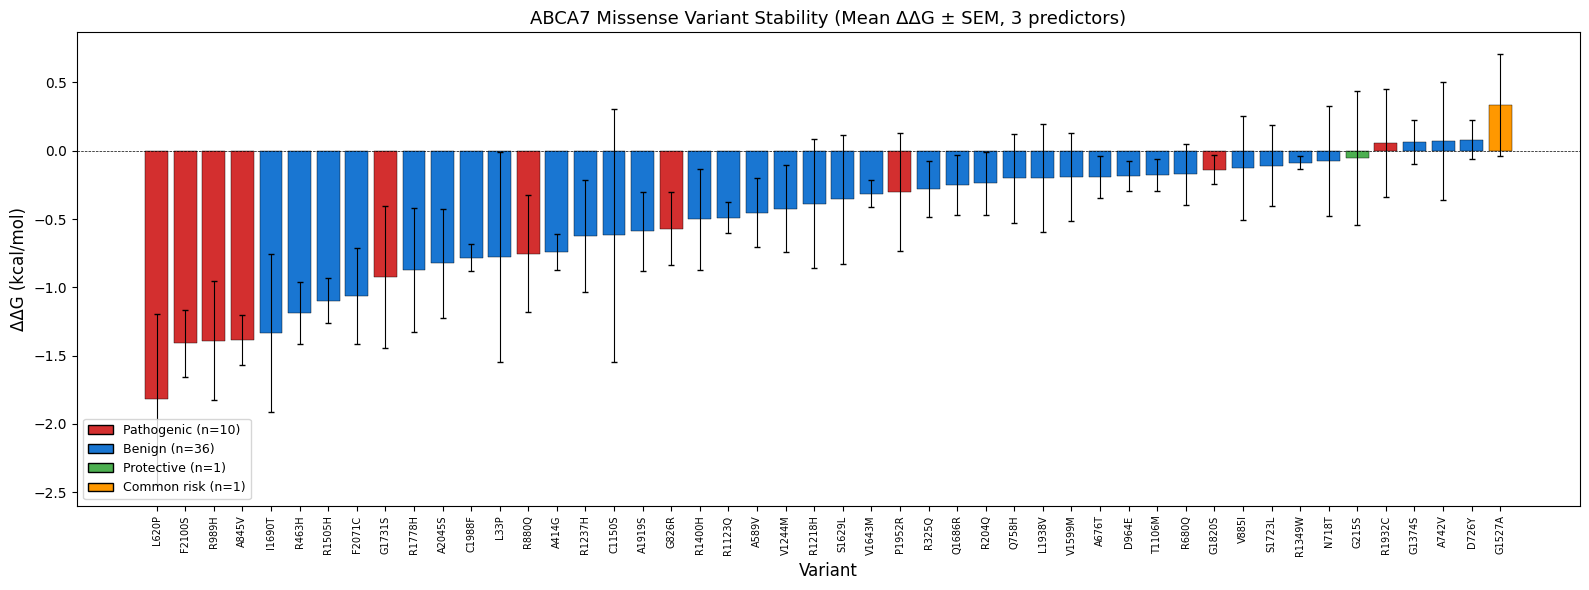

Saved: abca7_ddG_barplot.png and .svg


In [ ]:
import matplotlib.pyplot as plt

# Sort all variants by ddG_mean
plot_df = merged.sort_values('ddG_mean').reset_index(drop=True)

# Color by category
colors = []
for cat in plot_df['category']:
    if cat == 'pathogenic': colors.append('#D32F2F')
    elif cat == 'protective': colors.append('#4CAF50')
    elif cat == 'common_risk': colors.append('#FF9800')
    else: colors.append('#1976D2')

fig, ax = plt.subplots(figsize=(16, 6))

ax.bar(range(len(plot_df)), plot_df['ddG_mean'],
       yerr=plot_df['ddG_sem'], capsize=2, color=colors,
       edgecolor='black', linewidth=0.3, error_kw={'linewidth': 0.8})

ax.set_xticks(range(len(plot_df)))
ax.set_xticklabels(plot_df['variant'], rotation=90, fontsize=7)
ax.set_ylabel('ΔΔG (kcal/mol)', fontsize=12)
ax.set_xlabel('Variant', fontsize=12)
ax.axhline(y=0, color='black', linewidth=0.5, linestyle='--')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#D32F2F', edgecolor='black', label='Pathogenic (n=10)'),
    Patch(facecolor='#1976D2', edgecolor='black', label='Benign (n=36)'),
    Patch(facecolor='#4CAF50', edgecolor='black', label='Protective (n=1)'),
    Patch(facecolor='#FF9800', edgecolor='black', label='Common risk (n=1)'),
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=9)

ax.set_title('ABCA7 Missense Variant Stability (Mean ΔΔG ± SEM, 3 predictors)', fontsize=13)
plt.tight_layout()
plt.savefig('/content/abca7_ddG_barplot.png', dpi=300, bbox_inches='tight')
plt.savefig('/content/abca7_ddG_barplot.svg', bbox_inches='tight')
plt.show()
print("Saved: abca7_ddG_barplot.png and .svg")

In [ ]:
# Format for GraphPad: each variant gets 3 columns (ddmut, ddgemb, dynamut2)
# Sorted by position, not by ddG

# Sort by position
merged['position'] = merged['variant'].str.extract(r'(\d+)').astype(int)
gp = merged.sort_values('position').reset_index(drop=True)

# Build GraphPad table: each variant is a "Group" with 3 replicates
# Row 1: group headers (variant names)
# Row 2: subheaders (could be category)
# Rows 3-5: the 3 ddG values

output = pd.DataFrame()
for _, row in gp.iterrows():
    col_name = row['variant']
    vals = [row['ddG_ddmut'], row['ddG_ddgemb'], row['ddG_dynamut2']]
    output[col_name] = vals + [None] * (10 - len(vals))  # pad if needed

output = output.iloc[:3]  # only 3 rows needed
output.index = ['DDMut', 'DDGemb', 'DynaMut2']

output.to_csv('/content/abca7_graphpad_format.csv')
print(output.to_string())
print(f"\nSaved: /content/abca7_graphpad_format.csv")
print(f"Columns: {len(output.columns)} variants")

          L33P  R204Q  G215S  R325Q  A414G  R463H  A589V  L620P  A676T  R680Q  N718T  D726Y  A742V  Q758H  G826R  A845V  R880Q  V885I  D964E  R989H  T1106M  R1123Q  C1150S  R1218H  R1237H  V1244M  R1349W  G1374S  R1400H  R1505H  G1527A  V1599M  S1629L  V1643M  Q1686R  I1690T  S1723L  G1731S  R1778H  G1820S  A1919S  R1932C  L1938V  P1952R  C1988F  A2045S  F2071C  F2100S
DDMut    -2.26   0.19  -0.49   0.03  -0.88  -1.00   0.04  -2.49   0.07   0.02   0.46   0.19  -0.02   0.04  -0.06  -1.12  -0.14  -0.39  -0.36  -0.94    0.05   -0.32   -2.27    0.43    0.05   -0.11    0.00   -0.11   -0.36   -1.00   -0.06   -0.41    0.53   -0.13    0.09   -0.30   -0.08   -0.02    0.01   -0.06   -0.07    0.74   -0.11    0.55   -0.94   -0.43   -0.38   -1.05
DDGemb    0.31  -0.30   0.92  -0.21  -0.86  -1.64  -0.77  -2.39  -0.19   0.08  -0.87  -0.20   0.86  -0.85  -0.68  -1.74  -1.58   0.62   0.02  -2.26   -0.26   -0.45    0.94   -0.39   -1.36   -1.06   -0.11    0.38    0.05   -1.42    1.08   -0.61   -1.08   -0

In [ ]:
# Domain assignments from Duchateau 2024 Table S1
DOMAINS = {
    "TMD1_TM1": (21,46), "ECD1": (47,540), "TMD1_TM2": (541,574),
    "TMD1_TM3": (587,617), "TMD1_TM4": (624,647), "TMD1_TM5": (652,677),
    "TMD1_broken": (682,709), "TMD1_TM6": (729,755),
    "NBD1": (807,1020), "RD1": (1031,1150),
    "TMD2_TM7": (1236,1260), "ECD2": (1261,1519),
    "TMD2_TM8": (1520,1562), "TMD2_TM9": (1575,1611),
    "TMD2_TM10": (1615,1639), "TMD2_TM11": (1643,1671),
    "TMD2_broken": (1675,1716), "TMD2_TM12": (1730,1756),
    "NBD2": (1775,2003), "RD2": (2021,2103),
}

def assign_domain(pos):
    for name, (s, e) in DOMAINS.items():
        if s <= pos <= e: return name
    return "Other"

def assign_group(pos):
    groups = {
        "TMD1": [(21,46),(541,574),(587,617),(624,647),(652,677),(682,709),(729,755)],
        "ECD1": [(47,540)], "NBD1": [(807,1020)], "RD1": [(1031,1150)],
        "TMD2": [(1236,1260),(1520,1562),(1575,1611),(1615,1639),(1643,1671),(1675,1716),(1730,1756)],
        "ECD2": [(1261,1519)], "NBD2": [(1775,2003)], "RD2": [(2021,2103)],
    }
    for name, ranges in groups.items():
        for s, e in ranges:
            if s <= pos <= e: return name
    return "Other"

# Add to merged df
merged['position'] = merged['variant'].str.extract(r'(\d+)').astype(int)
merged['domain_fine'] = merged['position'].apply(assign_domain)
merged['domain_group'] = merged['position'].apply(assign_group)

# Sort by position
gp = merged.sort_values('position').reset_index(drop=True)

# Print full table
print(f"{'Variant':<10} {'Category':<13} {'Domain':<15} {'Group':<8} {'ddG_mean':>8}")
print("-" * 60)
for _, r in gp.iterrows():
    print(f"{r['variant']:<10} {r['category']:<13} {r['domain_fine']:<15} {r['domain_group']:<8} {r['ddG_mean']:>8.2f}")

# Summary: domain distribution by category
print("\n\nDomain distribution:")
ct = pd.crosstab(gp['domain_group'], gp['category'])
print(ct.to_string())

# Mean ddG by domain for pathogenic only
print("\n\nPathogenic ddG by domain:")
path = gp[gp['category']=='pathogenic']
print(path.groupby('domain_group')['ddG_mean'].agg(['mean','count']).round(2).to_string())

# GraphPad CSV with domain info in header
output = pd.DataFrame()
for _, row in gp.iterrows():
    col_name = f"{row['variant']}|{row['domain_group']}|{row['category']}"
    output[col_name] = [row['ddG_ddmut'], row['ddG_ddgemb'], row['ddG_dynamut2']]

output.index = ['DDMut', 'DDGemb', 'DynaMut2']
output.to_csv('/content/abca7_graphpad_with_domains.csv')
print(f"\nSaved: /content/abca7_graphpad_with_domains.csv")

Variant    Category      Domain          Group    ddG_mean
------------------------------------------------------------
L33P       benign        TMD1_TM1        TMD1        -0.78
R204Q      benign        ECD1            ECD1        -0.24
G215S      protective    ECD1            ECD1        -0.05
R325Q      benign        ECD1            ECD1        -0.28
A414G      benign        ECD1            ECD1        -0.74
R463H      benign        ECD1            ECD1        -1.19
A589V      benign        TMD1_TM3        TMD1        -0.45
L620P      pathogenic    Other           Other       -1.82
A676T      benign        TMD1_TM5        TMD1        -0.19
R680Q      benign        Other           Other       -0.17
N718T      benign        Other           Other       -0.08
D726Y      benign        Other           Other        0.08
A742V      benign        TMD1_TM6        TMD1         0.07
Q758H      benign        Other           Other       -0.20
G826R      pathogenic    NBD1            NBD1        -

# DSSP for Solvent Accessability

In [ ]:
# Install DSSP
!apt-get install dssp -y -q

# Test it works
!mkdssp --version

Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  libboost-iostreams1.74.0 libboost-program-options1.74.0 libboost-regex1.74.0
  libcifpp-data libcifpp2
The following NEW packages will be installed:
  dssp libboost-iostreams1.74.0 libboost-program-options1.74.0
  libboost-regex1.74.0 libcifpp-data libcifpp2
0 upgraded, 6 newly installed, 0 to remove and 5 not upgraded.
Need to get 3,034 kB of archives.
After this operation, 22.6 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libboost-iostreams1.74.0 amd64 1.74.0-14ubuntu3 [245 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libboost-program-options1.74.0 amd64 1.74.0-14ubuntu3 [311 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/main amd64 libboost-regex1.74.0 amd64 1.74.0-14ubuntu3 [511 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libcifpp-data all 2.0.5-1build1 [437 

In [ ]:
import subprocess
import pandas as pd
import re

# Run DSSP on open conformation
subprocess.run(['mkdssp', '--output-format', 'dssp', '/content/8EDW.pdb', '/content/8EDW.dssp'],
               capture_output=True)

# Parse DSSP output
dssp_data = []
with open('/content/8EDW.dssp', 'r') as f:
    parsing = False
    for line in f:
        if line.strip().startswith('#  RESIDUE'):
            parsing = True
            continue
        if not parsing:
            continue
        if len(line) < 40:
            continue

        try:
            res_num = int(line[5:10].strip())
            chain = line[11]
            aa = line[13]
            ss = line[16]  # secondary structure
            acc = int(line[35:38].strip())  # accessible surface area

            if chain == 'A' and aa != '!':  # skip chain breaks
                dssp_data.append({
                    'residue_id': res_num,
                    'aa': aa,
                    'ss': ss if ss != ' ' else 'C',  # C for coil
                    'acc': acc
                })
        except (ValueError, IndexError):
            continue

dssp_df = pd.DataFrame(dssp_data)

# Calculate RSA using Tien et al. (2013) max ASA values
max_asa = {
    'A':129,'R':274,'N':195,'D':193,'C':167,'E':223,'Q':225,'G':104,
    'H':224,'I':197,'L':201,'K':236,'M':224,'F':240,'P':159,'S':155,
    'T':172,'W':285,'Y':263,'V':174
}

dssp_df['max_asa'] = dssp_df['aa'].map(max_asa)
dssp_df['rsa'] = dssp_df['acc'] / dssp_df['max_asa']
dssp_df['rsa'] = dssp_df['rsa'].clip(0, 1)  # cap at 1

# Map to our variants
master_df = pd.read_csv('/content/abca7_master_variants.csv')
clean = master_df[master_df['in_open'] == True].copy()

clean = clean.merge(dssp_df[['residue_id','aa','ss','acc','rsa']],
                     left_on='position', right_on='residue_id', how='left')

# Summary
print(f"DSSP parsed: {len(dssp_df)} residues")
print(f"Variants with RSA: {clean['rsa'].notna().sum()}/{len(clean)}\n")

print(f"{'Variant':<10} {'Cat':<13} {'SS':<4} {'ACC':>5} {'RSA':>6}")
print("-" * 42)
for _, r in clean.sort_values('position').iterrows():
    print(f"{r['variant']:<10} {r['category']:<13} {r.get('ss','?'):<4} {r.get('acc',0):>5.0f} {r.get('rsa',0):>6.3f}")

clean.to_csv('/content/abca7_variants_with_rsa.csv', index=False)
print(f"\nSaved: /content/abca7_variants_with_rsa.csv")

DSSP parsed: 1804 residues
Variants with RSA: 47/48

Variant    Cat           SS     ACC    RSA
------------------------------------------
L33P       benign        H       27  0.134
R204Q      benign        H      147  0.536
G215S      protective    S        6  0.058
R325Q      benign        H       95  0.347
A414G      benign        C       48  0.372
R463H      benign        E        9  0.033
A589V      benign        H       46  0.357
L620P      pathogenic    S       10  0.050
A676T      benign        H       64  0.496
R680Q      benign        T      144  0.526
N718T      benign        G       19  0.097
D726Y      benign        T       48  0.249
A742V      benign        H       68  0.527
Q758H      benign        S      181  0.804
G826R      pathogenic    C       33  0.317
A845V      pathogenic    S        2  0.016
R880Q      pathogenic    G       52  0.190
V885I      benign        E       64  0.368
D964E      benign        C        9  0.047
R989H      pathogenic    S       31  0.113
T

In [ ]:
# Combine RSA with ddG data
rsa_df = clean[['variant','category','ss','acc','rsa','position']].copy()
ddg_df = pd.read_csv('/content/abca7_ddG_combined.csv')
combined = rsa_df.merge(ddg_df[['variant','ddG_mean','ddG_ddmut','ddG_ddgemb','ddG_dynamut2']], on='variant')

# Destabilizing benign variants (ddG_mean < -0.8)
ben_destab = combined[(combined['category']=='benign') & (combined['ddG_mean'] < -0.8)].sort_values('ddG_mean')
print("Significantly destabilizing BENIGN variants:")
print(f"{'Variant':<10} {'RSA':>6} {'SS':<4} {'ddG_mean':>8} {'Surface?'}")
print("-" * 45)
for _, r in ben_destab.iterrows():
    surface = "YES" if r['rsa'] > 0.25 else "NO"
    print(f"{r['variant']:<10} {r['rsa']:>6.3f} {r['ss']:<4} {r['ddG_mean']:>8.2f} {surface}")

print("\n\nPathogenic variants for comparison:")
path = combined[combined['category']=='pathogenic'].sort_values('ddG_mean')
print(f"{'Variant':<10} {'RSA':>6} {'SS':<4} {'ddG_mean':>8} {'Surface?'}")
print("-" * 45)
for _, r in path.iterrows():
    surface = "YES" if r['rsa'] > 0.25 else "NO"
    print(f"{r['variant']:<10} {r['rsa']:>6.3f} {r['ss']:<4} {r['ddG_mean']:>8.2f} {surface}")

# Key comparison: RSA of pathogenic vs benign
from scipy import stats
path_rsa = combined[combined['category']=='pathogenic']['rsa'].dropna()
ben_rsa = combined[combined['category']=='benign']['rsa'].dropna()
stat, p = stats.mannwhitneyu(path_rsa, ben_rsa)
print(f"\n\nRSA: pathogenic median={path_rsa.median():.3f} vs benign median={ben_rsa.median():.3f}")
print(f"Mann-Whitney p={p:.4f}")

# Are the destabilizing benign variants surface-exposed Arg?
print(f"\n\nAll Arg substitutions in benign set:")
arg_ben = combined[(combined['category']=='benign') & (combined['variant'].str.startswith('R'))]
print(f"{'Variant':<10} {'RSA':>6} {'ddG_mean':>8}")
for _, r in arg_ben.sort_values('ddG_mean').iterrows():
    print(f"{r['variant']:<10} {r['rsa']:>6.3f} {r['ddG_mean']:>8.2f}")

Significantly destabilizing BENIGN variants:
Variant       RSA SS   ddG_mean Surface?
---------------------------------------------
I1690T      0.467 T       -1.33 YES
R463H       0.033 E       -1.19 NO
R1505H      0.241 G       -1.10 NO
F2071C      0.033 H       -1.06 NO
R1778H      0.504 H       -0.87 YES
A2045S      0.147 C       -0.82 NO


Pathogenic variants for comparison:
Variant       RSA SS   ddG_mean Surface?
---------------------------------------------
L620P       0.050 S       -1.82 NO
F2100S      0.229 H       -1.41 NO
R989H       0.113 S       -1.39 NO
A845V       0.016 S       -1.39 NO
G1731S      0.183 H       -0.92 NO
R880Q       0.190 G       -0.75 NO
G826R       0.317 C       -0.57 YES
P1952R      0.025 C       -0.30 NO
G1820S      0.519 T       -0.14 YES
R1932C      0.274 H        0.06 YES


RSA: pathogenic median=0.186 vs benign median=0.339
Mann-Whitney p=0.0694


All Arg substitutions in benign set:
Variant       RSA ddG_mean
R463H       0.033    -1.19
R1505H   

In [ ]:
# RSA in same format as ddG GraphPad file
# Each variant = column, single row, sorted by position

gp_rsa = combined.sort_values('position').reset_index(drop=True)

output = pd.DataFrame()
for _, r in gp_rsa.iterrows():
    output[r['variant']] = [r['rsa']]

output.index = ['RSA']
output.to_csv('/content/abca7_rsa_graphpad.csv')
print(output.to_string())
print(f"\nSaved: /content/abca7_rsa_graphpad.csv")
print(f"Columns: {len(output.columns)} variants")

         L33P     R204Q     G215S     R325Q     A414G     R463H     A589V     L620P     A676T     R680Q     N718T     D726Y     A742V     Q758H     G826R     A845V     R880Q     V885I     D964E     R989H    T1106M    R1123Q  C1150S    R1218H    R1237H   V1244M    R1349W    G1374S    R1400H    R1505H    G1527A    V1599M  S1629L    V1643M    Q1686R    I1690T    S1723L    G1731S   R1778H    G1820S    A1919S    R1932C    L1938V    P1952R   C1988F    A2045S    F2071C    F2100S
RSA  0.134328  0.536496  0.057692  0.346715  0.372093  0.032847  0.356589  0.049751  0.496124  0.525547  0.097436  0.248705  0.527132  0.804444  0.317308  0.015504  0.189781  0.367816  0.046632  0.113139  0.610465  0.281022     NaN  0.463504  0.777372  0.33908  0.259124  0.423077  0.339416  0.240876  0.182692  0.132184     0.0  0.413793  0.413333  0.467005  0.264516  0.182692  0.50365  0.519231  0.108527  0.273723  0.059701  0.025157  0.02994  0.147287  0.033333  0.229167

Saved: /content/abca7_rsa_graphpad.csv
Column